In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Veriyi oku
df = pd.read_csv("data.csv")

# 2) İlk 5 satıra bak
print("İlk 5 satır:")
print(df.head())

# 3) Veri seti boyutu
print("\nVeri seti boyutu:", df.shape)

# 4) Sütun isimleri
print("\nSütunlar:")
print(df.columns.tolist())

# 5) Gereksiz sütunları sil
df = df.drop(columns=["id", "Unnamed: 32"])

# 6) diagnosis sütununu sayısala çevir
# M = 1, B = 0
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# 7) Girdi (X) ve hedef (y) ayır
X = df.drop(columns=["diagnosis"]).values
y = df["diagnosis"].values.reshape(-1, 1)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

# 8) Train / Test ayırma
# %80 train, %20 test
np.random.seed(42)

indices = np.arange(X.shape[0])
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split_index = int(0.8 * len(X))

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("\nTrain boyutu:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest boyutu:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# 9) Normalization
# Sadece train verisinin ortalama ve std'si ile normalize et
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Sıfıra bölme hatasını önlemek için
std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("\nNormalization tamamlandı.")
print("X_train ilk satır:")
print(X_train[0])

print("\ny_train ilk satır:")
print(y_train[0])

İlk 5 satır:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wors

In [3]:

# 1) Ağırlıkları başlat
np.random.seed(42)

input_size = 30
hidden_size = 16
output_size = 1

# Küçük random değerler
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

print("\nW1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

# 2) Sigmoid fonksiyonu

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# 3) Forward Propagation


# Gizli katman
Z1 = np.dot(X_train, W1) + b1
A1 = sigmoid(Z1)

# Çıkış katmanı
Z2 = np.dot(A1, W2) + b2
y_hat = sigmoid(Z2)

print("\nForward propagation tamamlandı.")
print("y_hat shape:", y_hat.shape)

print("\nİlk 5 tahmin:")
print(y_hat[:5])

print("\nGerçek değerler:")
print(y_train[:5])


W1 shape: (30, 16)
b1 shape: (1, 16)
W2 shape: (16, 1)
b2 shape: (1, 1)

Forward propagation tamamlandı.
y_hat shape: (455, 1)

İlk 5 tahmin:
[[0.49863629]
 [0.49855099]
 [0.49852123]
 [0.49873252]
 [0.49870019]]

Gerçek değerler:
[[0]
 [1]
 [1]
 [0]
 [0]]


In [4]:
# 4) Loss Hesabı
epsilon = 1e-8  # log(0) hatasını önlemek için

loss = -np.mean(
    y_train * np.log(y_hat + epsilon) + (1 - y_train) * np.log(1 - y_hat + epsilon)
)

print("\nLoss:", loss)


# 5) Backpropagation
m = X_train.shape[0]  # örnek sayısı

# Çıkış katmanı türevleri
dZ2 = y_hat - y_train                     # (455, 1)
dW2 = np.dot(A1.T, dZ2) / m              # (16, 1)
db2 = np.sum(dZ2, axis=0, keepdims=True) / m   # (1, 1)

# Gizli katman türevleri
dA1 = np.dot(dZ2, W2.T)                  # (455, 16)
dZ1 = dA1 * A1 * (1 - A1)                # sigmoid türevi
dW1 = np.dot(X_train.T, dZ1) / m         # (30, 16)
db1 = np.sum(dZ1, axis=0, keepdims=True) / m   # (1, 16)

print("\ndW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)
print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)

print("\nİlk birkaç gradient değeri:")
print("dW1[0][:5] =", dW1[0][:5])
print("dW2[:5] =\n", dW2[:5])


Loss: 0.692586057178819

dW1 shape: (30, 16)
db1 shape: (1, 16)
dW2 shape: (16, 1)
db2 shape: (1, 1)

İlk birkaç gradient değeri:
dW1[0][:5] = [ 0.00011414  0.00085218  0.00143186 -0.00018147  0.00067496]
dW2[:5] =
 [[0.06711117]
 [0.06556658]
 [0.0630436 ]
 [0.06428295]
 [0.06703932]]


In [5]:
# 6) Accuracy fonksiyonu
def compute_accuracy(y_true, y_pred):
    y_pred_class = (y_pred >= 0.5).astype(int)
    accuracy = np.mean(y_pred_class == y_true)
    return accuracy

# 7) Eğitim için parametreler
learning_rate = 0.1
epochs = 1000

loss_history = []


# 8) Eğitim Döngüsü
for epoch in range(epochs):
    
    # ---- Forward propagation ----
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    y_hat = sigmoid(Z2)

    # ---- Loss ----
    epsilon = 1e-8
    loss = -np.mean(
        y_train * np.log(y_hat + epsilon) + (1 - y_train) * np.log(1 - y_hat + epsilon)
    )

    # ---- Backpropagation ----
    m = X_train.shape[0]

    dZ2 = y_hat - y_train
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * A1 * (1 - A1)
    dW1 = np.dot(X_train.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # ---- Ağırlık güncelleme ----
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    loss_history.append(loss)

    # Her 100 epoch'ta bir bilgi yazdır
    if epoch % 100 == 0:
        train_acc = compute_accuracy(y_train, y_hat)
        print(f"Epoch {epoch}: Loss = {loss:.6f}, Train Accuracy = {train_acc:.4f}")

Epoch 0: Loss = 0.692586, Train Accuracy = 0.6374
Epoch 100: Loss = 0.484835, Train Accuracy = 0.6813
Epoch 200: Loss = 0.230352, Train Accuracy = 0.9473
Epoch 300: Loss = 0.137108, Train Accuracy = 0.9604
Epoch 400: Loss = 0.102224, Train Accuracy = 0.9802
Epoch 500: Loss = 0.085122, Train Accuracy = 0.9802
Epoch 600: Loss = 0.075252, Train Accuracy = 0.9868
Epoch 700: Loss = 0.068923, Train Accuracy = 0.9890
Epoch 800: Loss = 0.064543, Train Accuracy = 0.9890
Epoch 900: Loss = 0.061333, Train Accuracy = 0.9890


In [6]:
# 9) Test verisi üzerinde değerlendirme
Z1_test = np.dot(X_test, W1) + b1
A1_test = sigmoid(Z1_test)

Z2_test = np.dot(A1_test, W2) + b2
y_test_pred = sigmoid(Z2_test)

test_acc = compute_accuracy(y_test, y_test_pred)

print("\nTest Accuracy:", test_acc)

print("\nİlk 10 test tahmini:")
print((y_test_pred[:10] >= 0.5).astype(int))

print("\nİlk 10 gerçek test değeri:")
print(y_test[:10])


Test Accuracy: 0.9649122807017544

İlk 10 test tahmini:
[[1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]]

İlk 10 gerçek test değeri:
[[1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]]


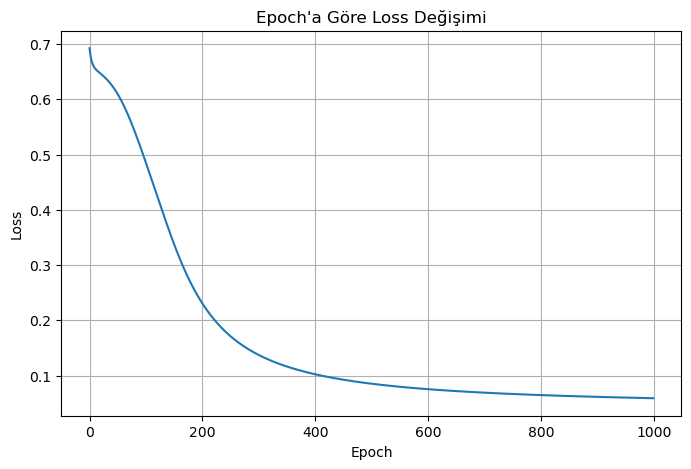

In [7]:
# 10) Loss Grafiği
plt.figure(figsize=(8, 5))                                                                                                                       
plt.plot(loss_history)
plt.title("Epoch'a Göre Loss Değişimi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

TP: 44
TN: 66
FP: 1
FN: 3


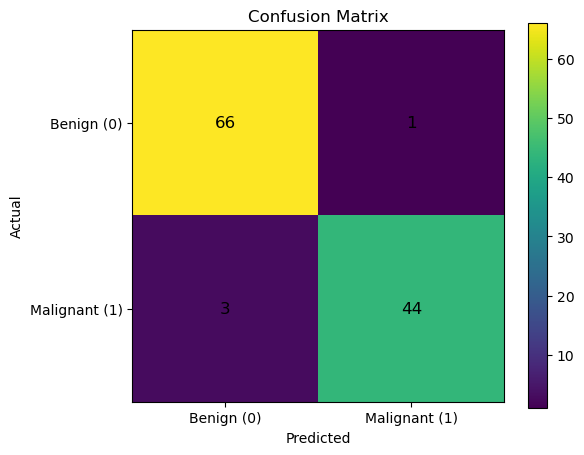

In [9]:
# Tahminleri sınıfa çevir
y_test_pred_class = (y_test_pred >= 0.5).astype(int)

# TP, TN, FP, FN hesapla
TP = np.sum((y_test == 1) & (y_test_pred_class == 1))
TN = np.sum((y_test == 0) & (y_test_pred_class == 0))
FP = np.sum((y_test == 0) & (y_test_pred_class == 1))
FN = np.sum((y_test == 1) & (y_test_pred_class == 0))

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

# Confusion Matrix Görsel

cm = np.array([[TN, FP],
               [FN, TP]])

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

labels = ["Benign (0)", "Malignant (1)"]
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

# Hücre içine değer yaz
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.colorbar()
plt.show()